In [1]:
import hisepy
import itertools
import os
import pandas as pd
import scanpy as sc
import sys

### Set up NSForest

In [2]:
import nsforest

In [3]:
output_folder = 'nsforest_output'
if not os.path.isdir(output_folder):
    os.mkdir(output_folder)

## Helper functions

In [4]:
def propagate_hierarchy(
    adata,
    hierarchy_df,
    from_level = 'AIFI_L3',
    to_levels = ['AIFI_L2', 'AIFI_L1'],
    keep_original = True,
    original_prefix = 'predicted_'
):
    obs = adata.obs
    
    for to_level in to_levels:
        prop_df = hierarchy_df[[from_level, to_level]]
        prop_df = prop_df.drop_duplicates()
        
        if keep_original:
            obs = obs.rename({to_level: original_prefix + to_level}, axis = 1)
        else:
            obs = obs.drop(to_level, axis = 1)

        obs[from_level] = obs[from_level].astype(str)
        obs = obs.merge(prop_df, on = from_level, how = 'left')
        obs[from_level] = obs[from_level].astype('category')
        obs[to_level] = obs[to_level].astype('category')
        
    obs = obs.set_index('barcodes', drop = False)
    adata.obs = obs

    return adata

In [5]:
def sample_groups(adata, group_list, n, random_state = 3030):
    group_vals = {}
    for group in group_list:
        unique_vals = adata.obs[group].unique().tolist()
        group_vals[group] = unique_vals

    group_combinations = list(itertools.product(*group_vals.values()))

    obs = adata.obs.copy()
    sampled_list = []
    for combo in group_combinations:
        sampled_obs = obs
        for i in range(len(group_list)):
            group = group_list[i]
            value = combo[i]
            sampled_obs = sampled_obs[sampled_obs[group] == value]
        if sampled_obs.shape[0] > n:
            sampled_obs = sampled_obs.sample(n = n, random_state = random_state, axis = 0)
        sampled_list = sampled_list + sampled_obs['barcodes'].tolist()

    sampled_adata = adata[adata.obs['barcodes'].isin(sampled_list)].copy()
    return sampled_adata

In [6]:
def run_nsforest(adata, cluster_header, output_folder):
    adata = adata.raw.to_adata()
    adata.raw = adata

    sc.pp.normalize_total(adata, target_sum = 1e4)
    sc.pp.log1p(adata)

    nsforest.ns.pp.dendrogram(
        adata, 
        cluster_header, 
        save = True, 
        output_folder = output_folder, 
        outputfilename_suffix = cluster_header
    )
    
    adata = nsforest.ns.pp.prep_medians(adata, cluster_header)
    adata = nsforest.ns.pp.prep_binary_scores(adata, cluster_header)

    results = nsforest.nsforesting.NSForest(
        adata,
        cluster_header,
        gene_selection = "BinaryFirst_moderate",
        save = True,
        save_supplementary = True,
        output_folder = output_folder,
        outputfilename_prefix = cluster_header
    )

    return adata, results

In [7]:
def nsforest_dotplot(adata, results, cluster_header):
    to_plot = results.copy()
    dendrogram = [] # custom dendrogram order
    dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
    to_plot["clusterName"] = to_plot["clusterName"].astype("category")
    to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
    to_plot = to_plot.sort_values("clusterName")
    to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})
    markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))

    markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
    markers_dict

    adata = adata.raw.to_adata()
    sc.pp.normalize_total(adata, target_sum = 1e4)
    sc.pp.log1p(adata)

    nsforest.ns.pl.dotplot(
        adata, 
        markers_dict, 
        cluster_header, 
        dendrogram = dendrogram, 
        save = False
    )

## Read cell type hierarchy

In [8]:
hierarchy_uuid = '1a44252c-8cab-4c8f-92c9-d8f3af633790'
hierarchy_csv = hisepy.cache_files([hierarchy_uuid])[0]
hierarchy_df = pd.read_csv(hierarchy_csv)

### Get Atlas dataset

In [9]:
uuid = 'cd100a30-5a2e-4ce6-8c73-840311c62b97'
h5ad = hisepy.cache_files([uuid])[0]

In [10]:
adata = sc.read_h5ad(h5ad)

In [11]:
adata = propagate_hierarchy(
    adata,
    hierarchy_df,
    original_prefix = 'atlas_'
)

In [12]:
adata.obs.columns

Index(['cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid',
       'pipeline.fileGuid', 'subject.biologicalSex', 'subject.birthYear',
       'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race',
       'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName',
       'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id',
       'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name',
       'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito',
       'doublet_score', 'atlas_AIFI_L1', 'atlas_AIFI_L2', 'AIFI_L3', 'AIFI_L2',
       'AIFI_L1'],
      dtype='object')

#### Separate CD4 and CD8; Promote gdT, DN T, and MAIT to L1.5

In [13]:
l1_types = adata.obs['AIFI_L1'].tolist()
l2_types = adata.obs['AIFI_L2'].tolist()
l1_5 = []
for i in range(len(l2_types)):
    l1 = l1_types[i]
    l2 = l2_types[i]

    new_type = l1
    
    if 'CD4' in l2:
        new_type = 'CD4 T cell'
    elif 'Treg' in l2:
        new_type = 'CD4 T cell'
    elif 'CD8' in l2:
        new_type = 'CD8 T cell'
    elif 'gdT' in l2:
        new_type = 'gdT'
    elif 'DN T' in l2:
        new_type = 'DN T cell'
    elif 'MAIT' in l2:
        new_type = 'MAIT'
    elif 'Proliferating T' in l2:
        new_type = 'Proliferating T cell'
    
    l1_5.append(new_type)

In [14]:
adata.obs['AIFI_L1.5'] = l1_5
adata.obs['AIFI_L1.5'] = adata.obs['AIFI_L1.5'].astype('category')

### L1 markers

In [15]:
l1_adata = sample_groups(adata, ['sample.sampleKitGuid', 'AIFI_L1'], 100)

In [16]:
l1_adata

AnnData object with n_obs × n_vars = 63450 × 1236
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.biologicalSex', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'barcodes', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'atlas_AIFI_L1', 'atlas_AIFI_L2', 'AIFI_L3', 'AIFI_L2', 'AIFI_L1', 'AIFI_L1.5'
    var: 'mito', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'AIFI_L1_colors', 'AIFI_L2_colors', 'AIFI_L3_colors', 'celltypist.low_colors', 'hvg', 'keep_colors', 'leiden', 'leiden_colors', 'log1p', 'neigh

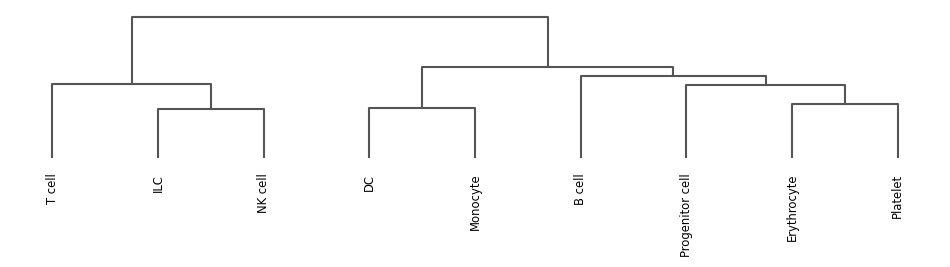

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 9/9 [02:29<00:00, 16.59s/it]


Saving calculated medians as adata.varm.medians_AIFI_L1
--- 149.36111974716187 seconds ---
median: 0.0
mean: 0.032438125
std: 0.25616744
Only positive genes selected. 2549 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 9/9 [00:03<00:00,  2.67it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L1
--- 3.389827013015747 seconds ---
median: 0.0
mean: 0.1949586310299645
std: 0.3260873417570752
Running NS-Forest version 4.1
Preparing adata...
--- 0.5537214279174805 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.5210459727870397
	Average number of genes after gene_selection in each cluster: 473.22222222222223
Saving number of genes selected per cluster as...
NSForest_AIFI_L1AIFI_L1_gene_selection.csv
Number of clusters to evaluate: 9
1 out of 9:
	B cell
	Pre-selected 123 genes to feed into Random Forest.
	  NSForest-selected markers: ['CD79A', 'MS4A1']
	  fbeta: 0.978
	  precision: 0.998
	  recall: 0.906
2 out of 9:
	DC
	Pre-selected 1457 genes to feed into Random Forest.
	  NSForest-selected markers: ['FCER1A', 'RNASE6']
	  fbeta: 0.885
	  precision: 0.955
	  recall: 0.686
3 out of 9:
	Erythrocyte
	Pre-selected 32 genes to feed into Random Forest.
	  NSF

Calculating medians (means) per cluster: 100%|██████████| 9/9 [00:00<00:00, 16.02it/s]

Saving supplementary table as...
NSForest_AIFI_L1AIFI_L1_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L1AIFI_L1_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L1AIFI_L1_results.csv
Saving final results table as...
NSForest_AIFI_L1AIFI_L1_results.pkl
--- 338.2122709751129 seconds ---


In [17]:
l1_adata, l1_results = run_nsforest(l1_adata, 'AIFI_L1', 'NSForest_AIFI_L1')

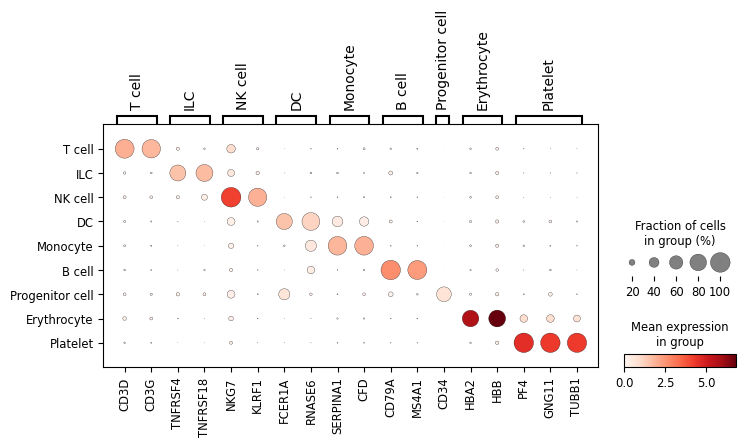

In [18]:
nsforest_dotplot(l1_adata, l1_results, 'AIFI_L1')

## AIFI_L1.5 results within each AIFI_L1 class

In [19]:
l1_l15_obs = adata.obs[['AIFI_L1','AIFI_L1.5']].copy().drop_duplicates()
l1_l15_counts = l1_l15_obs['AIFI_L1'].value_counts()
l1_classes = l1_l15_counts[l1_l15_counts > 1].index.tolist()
l1_classes

['T cell']

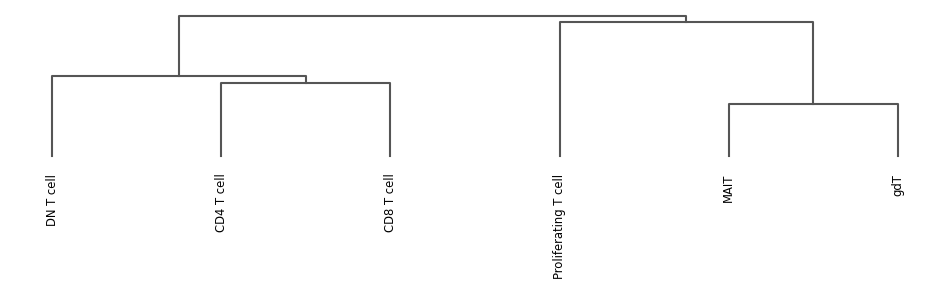

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 6/6 [01:32<00:00, 15.35s/it]


Saving calculated medians as adata.varm.medians_AIFI_L1.5
--- 92.1226761341095 seconds ---
median: 0.0
mean: 0.038076803
std: 0.2753922
Only positive genes selected. 2267 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 6/6 [00:02<00:00,  2.96it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L1.5
--- 2.045175552368164 seconds ---
median: 0.0
mean: 0.16720901355727985
std: 0.3312287106873539
Running NS-Forest version 4.1
Preparing adata...
--- 0.36750102043151855 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.49843772424463373
	Average number of genes after gene_selection in each cluster: 352.3333333333333
Saving number of genes selected per cluster as...
NSForest_AIFI_L1.5_T cellAIFI_L1.5_gene_selection.csv
Number of clusters to evaluate: 6
1 out of 6:
	CD4 T cell
	Pre-selected 31 genes to feed into Random Forest.
	  NSForest-selected markers: ['MAL']
	  fbeta: 0.583
	  precision: 0.595
	  recall: 0.539
2 out of 6:
	CD8 T cell
	Pre-selected 9 genes to feed into Random Forest.
	Only 9 out of 15 top Random Forest features with median > 0 will be further evaluated.
	  NSForest-selected markers: ['CD8B', 'CD8A']
	  fbeta: 0.712
	  precision: 0.739
	  

Calculating medians (means) per cluster: 100%|██████████| 6/6 [00:00<00:00, 19.14it/s]


Saving supplementary table as...
NSForest_AIFI_L1.5_T cellAIFI_L1.5_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L1.5_T cellAIFI_L1.5_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L1.5_T cellAIFI_L1.5_results.csv
Saving final results table as...
NSForest_AIFI_L1.5_T cellAIFI_L1.5_results.pkl
--- 165.18345165252686 seconds ---


In [20]:
l15_results = {}
for l1_class in l1_classes:
    l15_adata = adata[adata.obs['AIFI_L1'] == l1_class]
    l15_adata = sample_groups(l15_adata, ['sample.sampleKitGuid', 'AIFI_L1.5'], 100)
    l15_adata, l15_res = run_nsforest(l15_adata, 'AIFI_L1.5', f'NSForest_AIFI_L1.5_{l1_class}')
    l15_results[l1_class] = {'adata': l15_adata, 'results': l15_res}

### L1.5 Plots

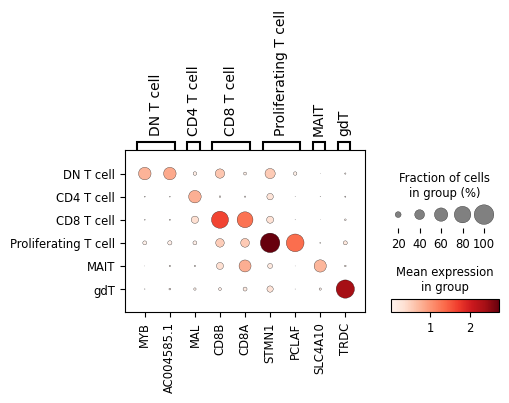

In [21]:
for res in l15_results.values():
    nsforest_dotplot(res['adata'], res['results'], 'AIFI_L1.5')

## AIFI_L2 results within each AIFI_L1.5 class

In [22]:
l15_l2_obs = adata.obs[['AIFI_L1.5','AIFI_L2']].copy().drop_duplicates()
l15_l2_counts = l15_l2_obs['AIFI_L1.5'].value_counts()
l15_classes = l15_l2_counts[l15_l2_counts > 1].index.tolist()

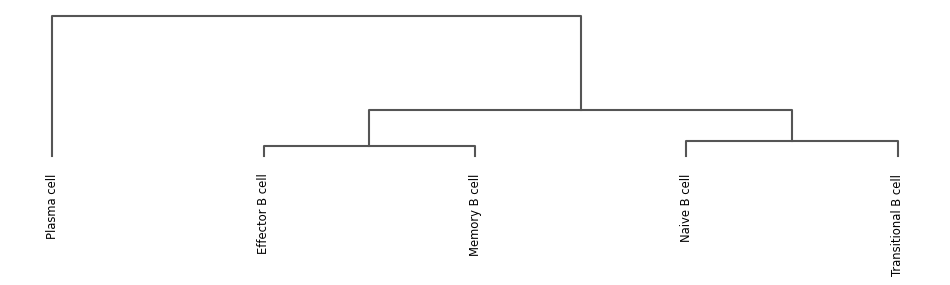

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 5/5 [00:40<00:00,  8.17s/it]


Saving calculated medians as adata.varm.medians_AIFI_L2
--- 40.834349632263184 seconds ---
median: 0.0
mean: 0.034073602
std: 0.26479283
Only positive genes selected. 2297 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 5/5 [00:01<00:00,  2.90it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L2
--- 1.747727632522583 seconds ---
median: 0.0
mean: 0.19691988057580573
std: 0.355399922744772
Running NS-Forest version 4.1
Preparing adata...
--- 0.17818570137023926 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.5523198033205777
	Average number of genes after gene_selection in each cluster: 406.8
Saving number of genes selected per cluster as...
NSForest_AIFI_L2_B cellAIFI_L2_gene_selection.csv
Number of clusters to evaluate: 5
1 out of 5:
	Effector B cell
	Pre-selected 245 genes to feed into Random Forest.
	  NSForest-selected markers: ['FCRL2', 'PLEK', 'CRIP1']
	  fbeta: 0.592
	  precision: 0.757
	  recall: 0.316
2 out of 5:
	Memory B cell
	Pre-selected 61 genes to feed into Random Forest.
	  NSForest-selected markers: ['AIM2']
	  fbeta: 0.561
	  precision: 0.583
	  recall: 0.49
3 out of 5:
	Naive B cell
	Pre-selected 22 genes to feed into Random Fores

Calculating medians (means) per cluster: 100%|██████████| 5/5 [00:00<00:00, 32.83it/s]


Saving supplementary table as...
NSForest_AIFI_L2_B cellAIFI_L2_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L2_B cellAIFI_L2_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L2_B cellAIFI_L2_results.csv
Saving final results table as...
NSForest_AIFI_L2_B cellAIFI_L2_results.pkl
--- 52.19246029853821 seconds ---


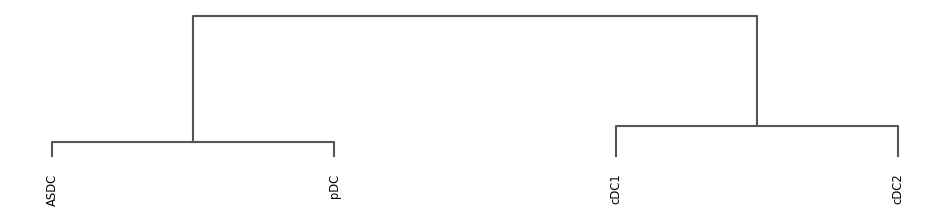

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 4/4 [00:20<00:00,  5.19s/it]


Saving calculated medians as adata.varm.medians_AIFI_L2
--- 20.75995421409607 seconds ---
median: 0.0
mean: 0.060273666
std: 0.30512214
Only positive genes selected. 2918 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 4/4 [00:01<00:00,  2.03it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L2
--- 2.0004894733428955 seconds ---
median: 0.03624574343363444
mean: 0.195550431358452
std: 0.2877027940567667
Running NS-Forest version 4.1
Preparing adata...
--- 0.12354063987731934 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.48325322541521865
	Average number of genes after gene_selection in each cluster: 435.75
Saving number of genes selected per cluster as...
NSForest_AIFI_L2_DCAIFI_L2_gene_selection.csv
Number of clusters to evaluate: 4
1 out of 4:
	ASDC
	Pre-selected 325 genes to feed into Random Forest.
	  NSForest-selected markers: ['AXL', 'PPP1R14A']
	  fbeta: 0.842
	  precision: 0.986
	  recall: 0.533
2 out of 4:
	cDC1
	Pre-selected 703 genes to feed into Random Forest.
	  NSForest-selected markers: ['CLEC9A', 'C1orf54']
	  fbeta: 0.977
	  precision: 0.999
	  recall: 0.9
3 out of 4:
	cDC2
	Pre-selected 406 genes to feed into Random Forest.
	  N

Calculating medians (means) per cluster: 100%|██████████| 4/4 [00:00<00:00, 30.68it/s]


Saving supplementary table as...
NSForest_AIFI_L2_DCAIFI_L2_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L2_DCAIFI_L2_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L2_DCAIFI_L2_results.csv
Saving final results table as...
NSForest_AIFI_L2_DCAIFI_L2_results.pkl
--- 29.227662086486816 seconds ---


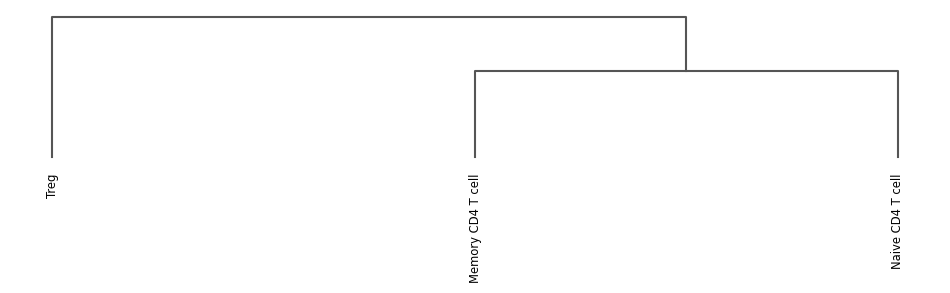

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:29<00:00,  9.69s/it]


Saving calculated medians as adata.varm.medians_AIFI_L2
--- 29.06427264213562 seconds ---
median: 0.0
mean: 0.029795427
std: 0.26450372
Only positive genes selected. 690 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 3/3 [00:00<00:00,  9.64it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L2
--- 0.3201315402984619 seconds ---
median: 0.01973457634449005
mean: 0.13267535493857618
std: 0.2546741968319343
Running NS-Forest version 4.1
Preparing adata...
--- 0.01670384407043457 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.3873495517705105
	Average number of genes after gene_selection in each cluster: 110.33333333333333
Saving number of genes selected per cluster as...
NSForest_AIFI_L2_CD4 T cellAIFI_L2_gene_selection.csv
Number of clusters to evaluate: 3
1 out of 3:
	Memory CD4 T cell
	Pre-selected 196 genes to feed into Random Forest.
	  NSForest-selected markers: ['ANXA1']
	  fbeta: 0.685
	  precision: 0.677
	  recall: 0.722
2 out of 3:
	Naive CD4 T cell
	Pre-selected 40 genes to feed into Random Forest.
	  NSForest-selected markers: ['CCR7', 'NUCB2']
	  fbeta: 0.599
	  precision: 0.695
	  recall: 0.386
3 out of 3:
	Treg
	Pre-selected 95 genes 

Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:00<00:00, 30.77it/s]

Saving supplementary table as...
NSForest_AIFI_L2_CD4 T cellAIFI_L2_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L2_CD4 T cellAIFI_L2_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L2_CD4 T cellAIFI_L2_results.csv
Saving final results table as...
NSForest_AIFI_L2_CD4 T cellAIFI_L2_results.pkl
--- 22.619269847869873 seconds ---


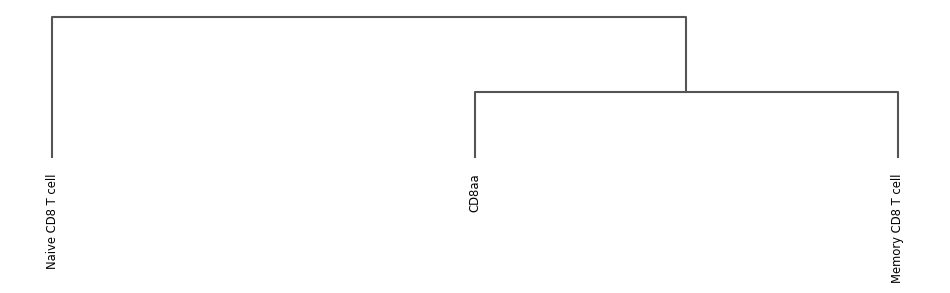

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:23<00:00,  7.84s/it]


Saving calculated medians as adata.varm.medians_AIFI_L2
--- 23.51613759994507 seconds ---
median: 0.0
mean: 0.03047763
std: 0.26529416
Only positive genes selected. 723 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 3/3 [00:00<00:00,  5.70it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L2
--- 0.5357935428619385 seconds ---
median: 0.024949342012405396
mean: 0.15070932509988175
std: 0.27691111460771645
Running NS-Forest version 4.1
Preparing adata...
--- 0.015970468521118164 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.4276204397075982
	Average number of genes after gene_selection in each cluster: 110.66666666666667
Saving number of genes selected per cluster as...
NSForest_AIFI_L2_CD8 T cellAIFI_L2_gene_selection.csv
Number of clusters to evaluate: 3
1 out of 3:
	CD8aa
	Pre-selected 69 genes to feed into Random Forest.
	  NSForest-selected markers: ['NCR3', 'ZNF683']
	  fbeta: 0.67
	  precision: 0.891
	  recall: 0.336
2 out of 3:
	Memory CD8 T cell
	Pre-selected 131 genes to feed into Random Forest.
	  NSForest-selected markers: ['GZMA']
	  fbeta: 0.863
	  precision: 0.897
	  recall: 0.749
3 out of 3:
	Naive CD8 T cell
	Pre-selected 132 ge

Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:00<00:00, 33.67it/s]

Saving supplementary table as...
NSForest_AIFI_L2_CD8 T cellAIFI_L2_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L2_CD8 T cellAIFI_L2_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L2_CD8 T cellAIFI_L2_results.csv
Saving final results table as...
NSForest_AIFI_L2_CD8 T cellAIFI_L2_results.pkl
--- 18.96827793121338 seconds ---


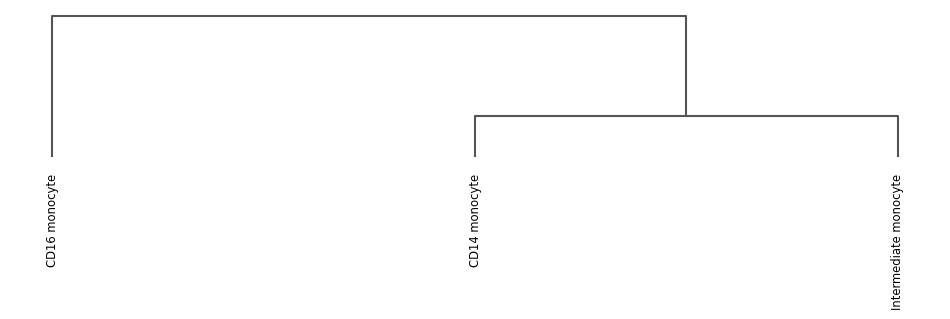

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:27<00:00,  9.18s/it]


Saving calculated medians as adata.varm.medians_AIFI_L2
--- 27.531795501708984 seconds ---
median: 0.0
mean: 0.050487433
std: 0.29795536
Only positive genes selected. 1672 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 3/3 [00:00<00:00,  3.86it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L2
--- 0.7931122779846191 seconds ---
median: 0.02809441089630127
mean: 0.16835794279402333
std: 0.2814483179321686
Running NS-Forest version 4.1
Preparing adata...
--- 0.0974886417388916 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.44980626072619195
	Average number of genes after gene_selection in each cluster: 313.3333333333333
Saving number of genes selected per cluster as...
NSForest_AIFI_L2_MonocyteAIFI_L2_gene_selection.csv
Number of clusters to evaluate: 3
1 out of 3:
	CD14 monocyte
	Pre-selected 116 genes to feed into Random Forest.
	  NSForest-selected markers: ['S100A12']
	  fbeta: 0.842
	  precision: 0.848
	  recall: 0.816
2 out of 3:
	CD16 monocyte
	Pre-selected 501 genes to feed into Random Forest.
	  NSForest-selected markers: ['FCGR3A', 'CDKN1C']
	  fbeta: 0.953
	  precision: 0.983
	  recall: 0.849
3 out of 3:
	Intermediate monocyte
	Pre-selec

Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:00<00:00, 23.97it/s]


Saving supplementary table as...
NSForest_AIFI_L2_MonocyteAIFI_L2_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L2_MonocyteAIFI_L2_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L2_MonocyteAIFI_L2_results.csv
Saving final results table as...
NSForest_AIFI_L2_MonocyteAIFI_L2_results.pkl
--- 32.181236743927 seconds ---


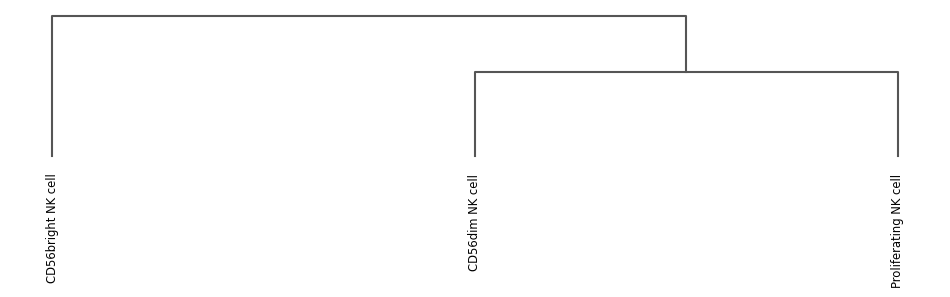

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:23<00:00,  7.70s/it]


Saving calculated medians as adata.varm.medians_AIFI_L2
--- 23.094728469848633 seconds ---
median: 0.0
mean: 0.038999587
std: 0.2753737
Only positive genes selected. 1246 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 3/3 [00:00<00:00,  5.08it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L2
--- 0.6049530506134033 seconds ---
median: 0.013694271445274353
mean: 0.20631305721910834
std: 0.34269481646489436
Running NS-Forest version 4.1
Preparing adata...
--- 0.02385401725769043 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.5490078736840027
	Average number of genes after gene_selection in each cluster: 198.0
Saving number of genes selected per cluster as...
NSForest_AIFI_L2_NK cellAIFI_L2_gene_selection.csv
Number of clusters to evaluate: 3
1 out of 3:
	CD56bright NK cell
	Pre-selected 68 genes to feed into Random Forest.
	  NSForest-selected markers: ['GZMK', 'SELL']
	  fbeta: 0.897
	  precision: 0.943
	  recall: 0.751
2 out of 3:
	CD56dim NK cell
	Pre-selected 33 genes to feed into Random Forest.
	  NSForest-selected markers: ['CLIC3', 'FGFBP2']
	  fbeta: 0.725
	  precision: 0.752
	  recall: 0.632
3 out of 3:
	Proliferating NK cell
	Pre-selecte

Calculating medians (means) per cluster: 100%|██████████| 3/3 [00:00<00:00, 29.12it/s]

Saving supplementary table as...
NSForest_AIFI_L2_NK cellAIFI_L2_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L2_NK cellAIFI_L2_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L2_NK cellAIFI_L2_results.csv
Saving final results table as...
NSForest_AIFI_L2_NK cellAIFI_L2_results.pkl
--- 22.578638315200806 seconds ---


In [23]:
l2_results = {}
for l15_class in l15_classes:
    l2_adata = adata[adata.obs['AIFI_L1.5'] == l15_class]
    l2_adata = sample_groups(l2_adata, ['sample.sampleKitGuid', 'AIFI_L2'], 50)
    l2_adata, l2_res = run_nsforest(l2_adata, 'AIFI_L2', f'NSForest_AIFI_L2_{l15_class}')
    l2_results[l15_class] = {'adata': l2_adata, 'results': l2_res}

### L2 Plots

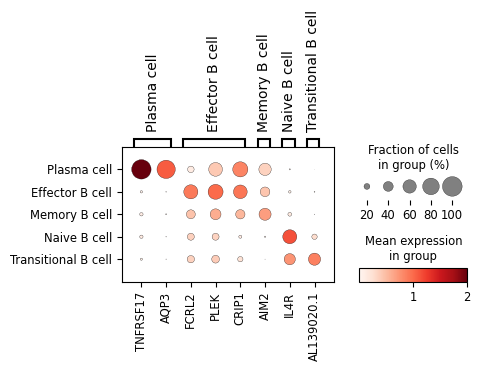

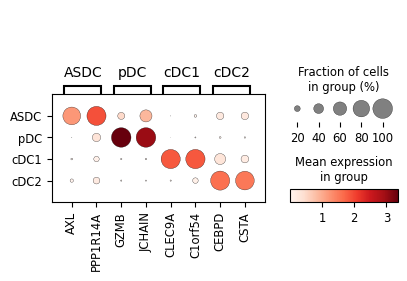

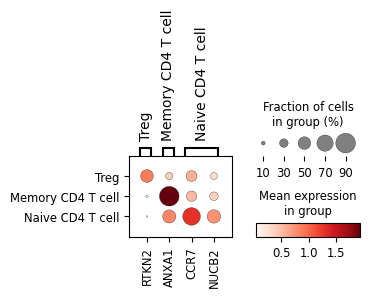

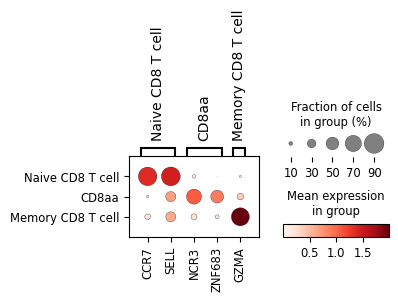

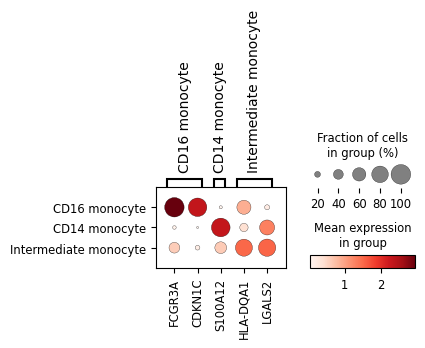

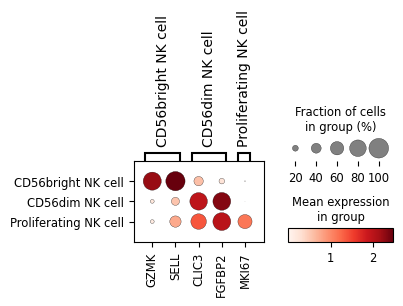

In [24]:
for res in l2_results.values():
    nsforest_dotplot(res['adata'], res['results'], 'AIFI_L2')

## AIFI_L3 results within each AIFI_L2 class

In [25]:
l2_l3_obs = adata.obs[['AIFI_L2','AIFI_L3']].copy().drop_duplicates()
l2_l3_counts = l2_l3_obs['AIFI_L2'].value_counts()
l2_classes = l2_l3_counts[l2_l3_counts > 1].index.tolist()

In [26]:
l2_classes

['Memory CD8 T cell',
 'Treg',
 'gdT',
 'Memory CD4 T cell',
 'Memory B cell',
 'CD56dim NK cell',
 'Naive CD4 T cell',
 'cDC2',
 'Progenitor cell',
 'Naive CD8 T cell',
 'CD16 monocyte',
 'MAIT',
 'CD14 monocyte',
 'Naive B cell',
 'Effector B cell']

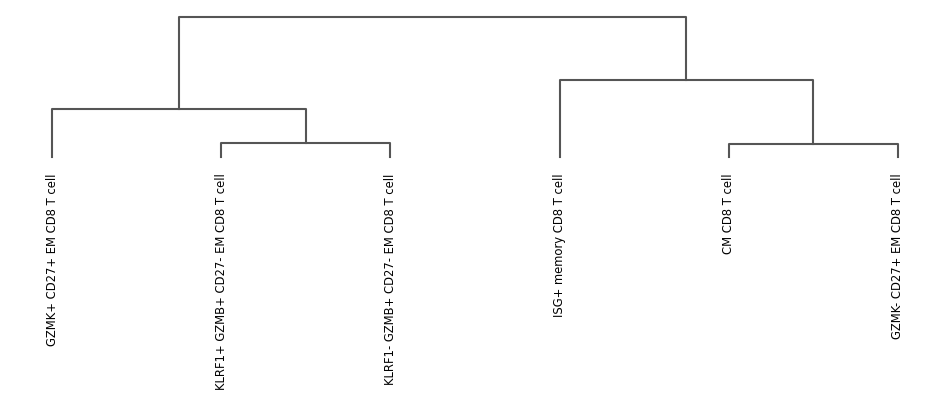

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 6/6 [01:25<00:00, 14.19s/it]


Saving calculated medians as adata.varm.medians_AIFI_L3
--- 85.1281487941742 seconds ---
median: 0.0
mean: 0.03258131
std: 0.26873097
Only positive genes selected. 866 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 6/6 [00:00<00:00,  7.88it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L3
--- 0.7719025611877441 seconds ---
median: 0.01982641816139221
mean: 0.1274574261064067
std: 0.23887299403304202
Running NS-Forest version 4.1
Preparing adata...
--- 0.14255523681640625 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.3663304201394487
	Average number of genes after gene_selection in each cluster: 116.16666666666667
Saving number of genes selected per cluster as...
NSForest_AIFI_L3_Memory CD8 T cellAIFI_L3_gene_selection.csv
Number of clusters to evaluate: 6
1 out of 6:
	CM CD8 T cell
	Pre-selected 68 genes to feed into Random Forest.
	  NSForest-selected markers: ['SELL', 'RCAN3']
	  fbeta: 0.583
	  precision: 0.688
	  recall: 0.363
2 out of 6:
	GZMK+ CD27+ EM CD8 T cell
	Pre-selected 59 genes to feed into Random Forest.
	  NSForest-selected markers: ['GZMK', 'CST7']
	  fbeta: 0.638
	  precision: 0.624
	  recall: 0.7
3 out of 6:
	GZMK- CD27+ 

Calculating medians (means) per cluster: 100%|██████████| 6/6 [00:00<00:00, 20.60it/s]


Saving supplementary table as...
NSForest_AIFI_L3_Memory CD8 T cellAIFI_L3_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L3_Memory CD8 T cellAIFI_L3_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L3_Memory CD8 T cellAIFI_L3_results.csv
Saving final results table as...
NSForest_AIFI_L3_Memory CD8 T cellAIFI_L3_results.pkl
--- 117.8734200000763 seconds ---


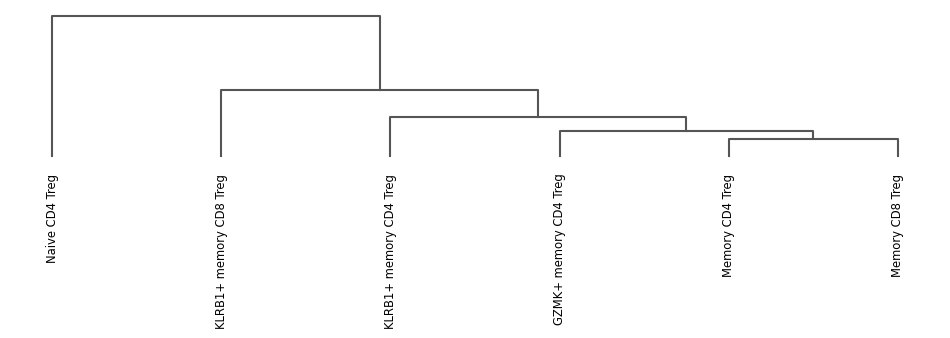

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 6/6 [00:47<00:00,  7.96s/it]


Saving calculated medians as adata.varm.medians_AIFI_L3
--- 47.73888087272644 seconds ---
median: 0.0
mean: 0.034195278
std: 0.27006385
Only positive genes selected. 1418 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 6/6 [00:01<00:00,  4.70it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L3
--- 1.2914495468139648 seconds ---
median: 0.0
mean: 0.14884482312774122
std: 0.29665692000492616
Running NS-Forest version 4.1
Preparing adata...
--- 0.13064289093017578 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.4455017431326674
	Average number of genes after gene_selection in each cluster: 188.33333333333334
Saving number of genes selected per cluster as...
NSForest_AIFI_L3_TregAIFI_L3_gene_selection.csv
Number of clusters to evaluate: 6
1 out of 6:
	GZMK+ memory CD4 Treg
	Pre-selected 11 genes to feed into Random Forest.
	  NSForest-selected markers: ['GZMK', 'AQP3']
	  fbeta: 0.441
	  precision: 0.474
	  recall: 0.345
2 out of 6:
	KLRB1+ memory CD4 Treg
	Pre-selected 176 genes to feed into Random Forest.
	  NSForest-selected markers: ['KLRB1', 'MAF']
	  fbeta: 0.552
	  precision: 0.663
	  recall: 0.33
3 out of 6:
	KLRB1+ memory CD8 Treg
	Pre-select

Calculating medians (means) per cluster: 100%|██████████| 6/6 [00:00<00:00, 32.18it/s]


Saving supplementary table as...
NSForest_AIFI_L3_TregAIFI_L3_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L3_TregAIFI_L3_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L3_TregAIFI_L3_results.csv
Saving final results table as...
NSForest_AIFI_L3_TregAIFI_L3_results.pkl
--- 58.45231890678406 seconds ---


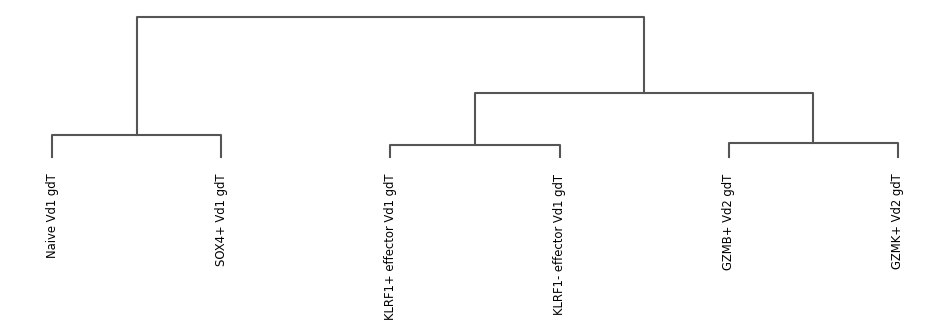

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 6/6 [00:47<00:00,  7.95s/it]


Saving calculated medians as adata.varm.medians_AIFI_L3
--- 47.67720341682434 seconds ---
median: 0.0
mean: 0.032045294
std: 0.2677844
Only positive genes selected. 832 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 6/6 [00:00<00:00,  8.02it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L3
--- 0.7587358951568604 seconds ---
median: 0.025540375709533693
mean: 0.140157508974274
std: 0.23880398986363344
Running NS-Forest version 4.1
Preparing adata...
--- 0.03183627128601074 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.3789614988379074
	Average number of genes after gene_selection in each cluster: 134.33333333333334
Saving number of genes selected per cluster as...
NSForest_AIFI_L3_gdTAIFI_L3_gene_selection.csv
Number of clusters to evaluate: 6
1 out of 6:
	GZMB+ Vd2 gdT
	Pre-selected 128 genes to feed into Random Forest.
	  NSForest-selected markers: ['TRGC1', 'KLRB1', 'GZMB']
	  fbeta: 0.626
	  precision: 0.689
	  recall: 0.459
2 out of 6:
	GZMK+ Vd2 gdT
	Pre-selected 141 genes to feed into Random Forest.
	  NSForest-selected markers: ['GZMK', 'KLRB1']
	  fbeta: 0.844
	  precision: 0.867
	  recall: 0.765
3 out of 6:
	KLRF1+ effector Vd1 gdT


Calculating medians (means) per cluster: 100%|██████████| 6/6 [00:00<00:00, 31.58it/s]


Saving supplementary table as...
NSForest_AIFI_L3_gdTAIFI_L3_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L3_gdTAIFI_L3_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L3_gdTAIFI_L3_results.csv
Saving final results table as...
NSForest_AIFI_L3_gdTAIFI_L3_results.pkl
--- 76.52572774887085 seconds ---


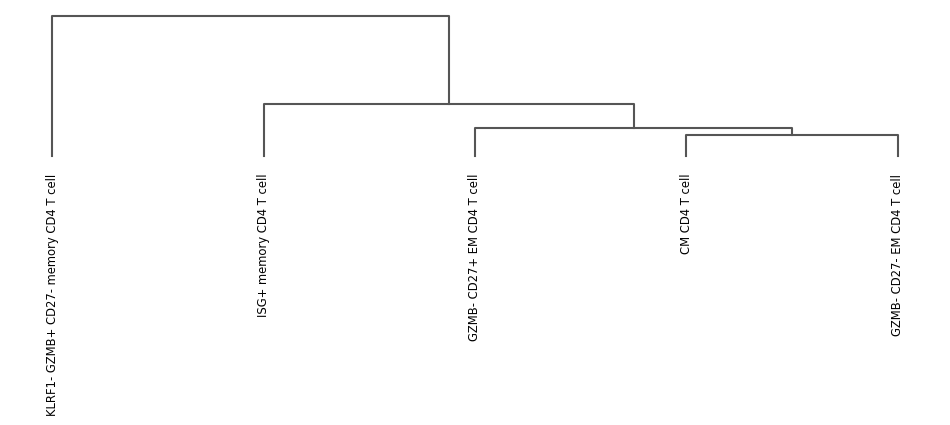

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 5/5 [01:15<00:00, 15.14s/it]


Saving calculated medians as adata.varm.medians_AIFI_L3
--- 75.70185995101929 seconds ---
median: 0.0
mean: 0.03304495
std: 0.27064487
Only positive genes selected. 843 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 5/5 [00:00<00:00,  7.90it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L3
--- 0.64335036277771 seconds ---
median: 0.018056243658065796
mean: 0.11261784583860444
std: 0.21743148616395377
Running NS-Forest version 4.1
Preparing adata...
--- 0.12833237648010254 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.3300493320025582
	Average number of genes after gene_selection in each cluster: 83.2
Saving number of genes selected per cluster as...
NSForest_AIFI_L3_Memory CD4 T cellAIFI_L3_gene_selection.csv
Number of clusters to evaluate: 5
1 out of 5:
	CM CD4 T cell
	Pre-selected 44 genes to feed into Random Forest.
	  NSForest-selected markers: ['CCR7', 'SELL']
	  fbeta: 0.492
	  precision: 0.533
	  recall: 0.375
2 out of 5:
	GZMB- CD27+ EM CD4 T cell
	Pre-selected 30 genes to feed into Random Forest.
	  NSForest-selected markers: ['GZMK']
	  fbeta: 0.65
	  precision: 0.709
	  recall: 0.486
3 out of 5:
	GZMB- CD27- EM CD4 T cell
	Pre-sel

Calculating medians (means) per cluster: 100%|██████████| 5/5 [00:00<00:00, 20.96it/s]


Saving supplementary table as...
NSForest_AIFI_L3_Memory CD4 T cellAIFI_L3_markers_onTarget_supp.csv
Saving supplementary table as...
NSForest_AIFI_L3_Memory CD4 T cellAIFI_L3_markers_onTarget.csv
Saving final results table as...
NSForest_AIFI_L3_Memory CD4 T cellAIFI_L3_results.csv
Saving final results table as...
NSForest_AIFI_L3_Memory CD4 T cellAIFI_L3_results.pkl
--- 81.35621118545532 seconds ---


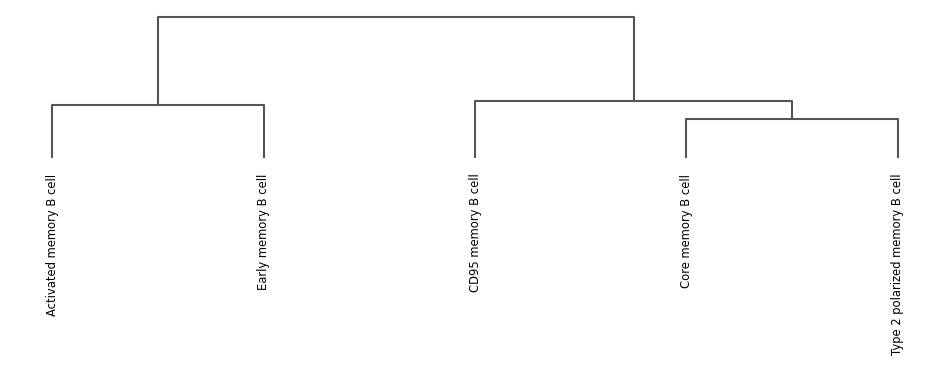

Calculating medians...


Calculating medians (means) per cluster: 100%|██████████| 5/5 [00:34<00:00,  6.86s/it]


Saving calculated medians as adata.varm.medians_AIFI_L3
--- 34.29243040084839 seconds ---
median: 0.0
mean: 0.034938447
std: 0.2721867
Only positive genes selected. 1619 positive genes out of 33538 total genes
Calculating binary scores...


Calculating binary scores per cluster: 100%|██████████| 5/5 [00:01<00:00,  4.20it/s]


Saving calculated binary scores as adata.varm.binary_scores_AIFI_L3
--- 1.2072973251342773 seconds ---
median: 0.0
mean: 0.16472258113688198
std: 0.3311235768773209
Running NS-Forest version 4.1
Preparing adata...
--- 0.10959291458129883 seconds ---
Pre-selecting genes based on binary scores...
	BinaryFirst_moderate Threshold (mean + 1 * std): 0.4958461580142029
	Average number of genes after gene_selection in each cluster: 258.6
Saving number of genes selected per cluster as...
NSForest_AIFI_L3_Memory B cellAIFI_L3_gene_selection.csv
Number of clusters to evaluate: 5
1 out of 5:
	Activated memory B cell
	Pre-selected 172 genes to feed into Random Forest.
	  NSForest-selected markers: ['EGR3']
	  fbeta: 0.738
	  precision: 0.766
	  recall: 0.644
2 out of 5:
	CD95 memory B cell
	Pre-selected 1032 genes to feed into Random Forest.
	  NSForest-selected markers: ['TKT', 'ANXA4', 'JPT1']
	  fbeta: 0.66
	  precision: 0.824
	  recall: 0.368
3 out of 5:
	Core memory B cell
	Pre-selected 32 gen

In [ ]:
l3_results = {}
for l2_class in l2_classes:
    l3_adata = adata[adata.obs['AIFI_L2'] == l2_class]
    l3_adata = sample_groups(l3_adata, ['sample.sampleKitGuid', 'AIFI_L3'], 100)
    l3_adata, l3_res = run_nsforest(l3_adata, 'AIFI_L3', f'NSForest_AIFI_L3_{l2_class}')
    l3_results[l2_class] = {'adata': l3_adata, 'results': l3_res}

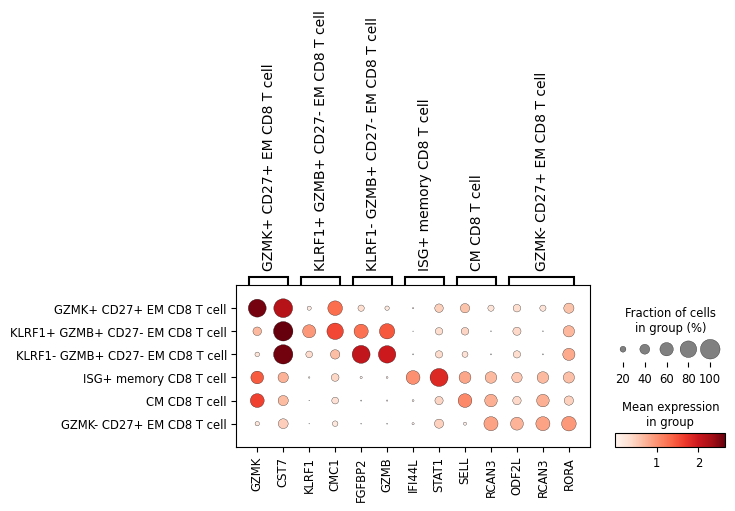

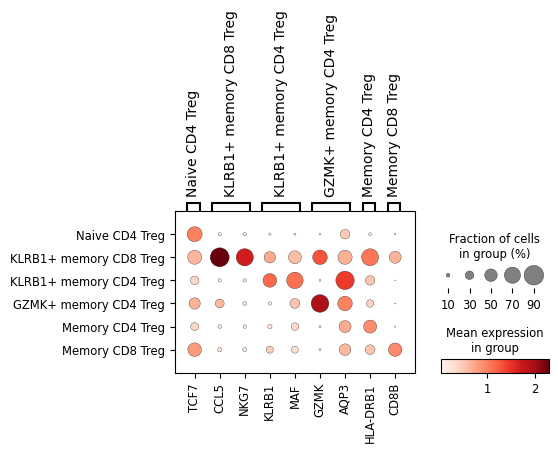

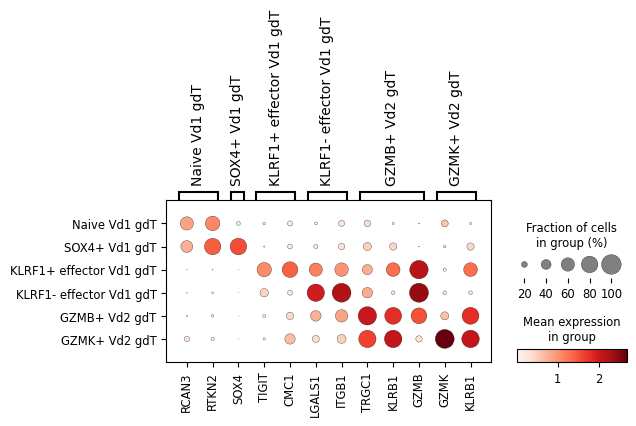

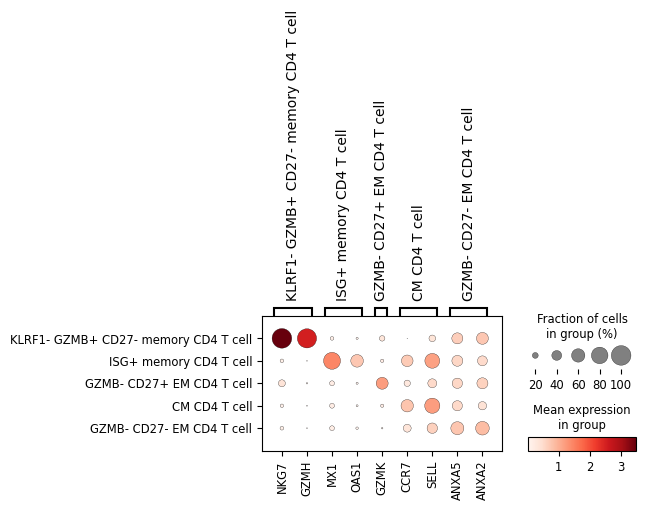

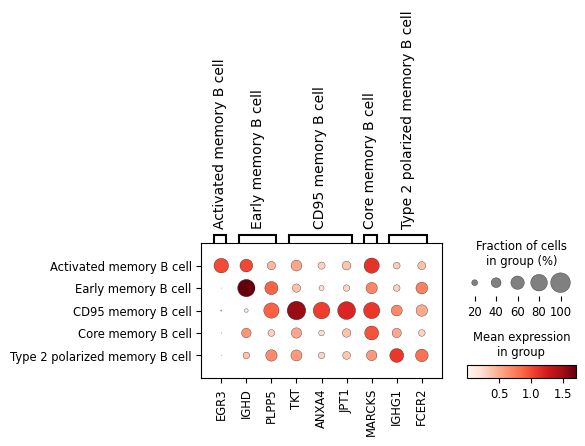

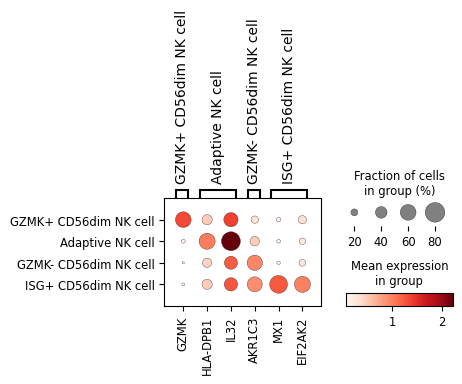

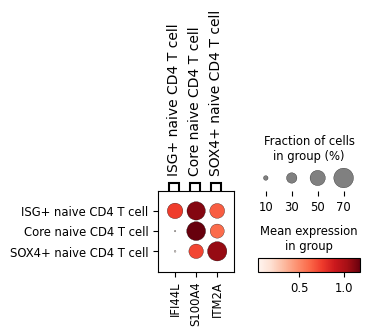

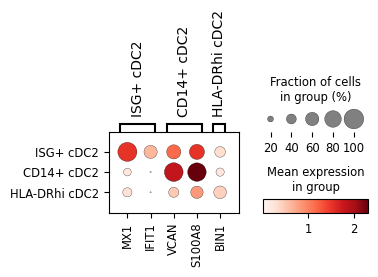

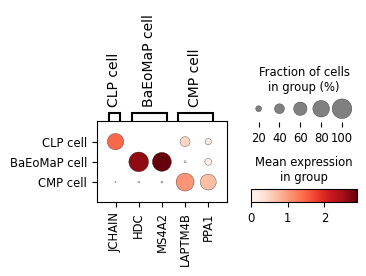

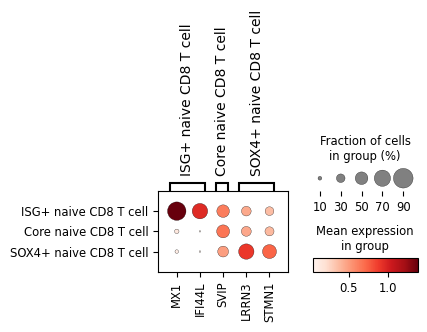

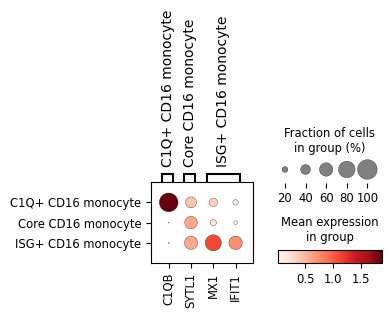

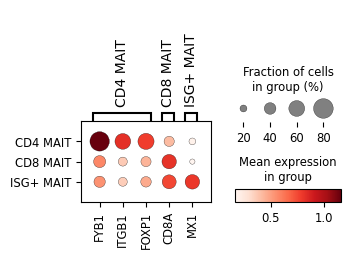

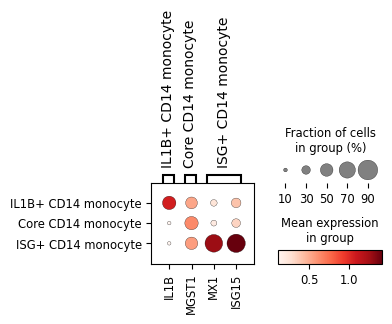

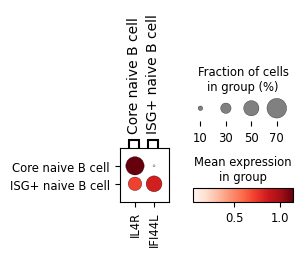

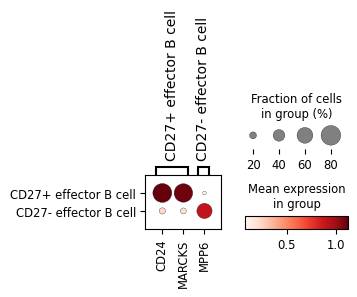

In [29]:
for res in l3_results.values():
    nsforest_dotplot(res['adata'], res['results'], 'AIFI_L3')

In [30]:
all_l1_res = l1_results

In [37]:
all_l15_res = []
for res in l15_results.values():
    all_l15_res.append(res['results'])
all_l15_res = pd.concat(all_l15_res)

In [33]:
all_l2_res = []
for res in l2_results.values():
    all_l2_res.append(res['results'])
all_l2_res = pd.concat(all_l2_res)

In [38]:
all_l3_res = []
for res in l3_results.values():
    all_l3_res.append(res['results'])
all_l3_res = pd.concat(all_l3_res)

In [46]:
all_res = pd.concat([all_l1_res, all_l15_res, all_l2_res, all_l3_res])

In [47]:
all_res.columns

Index(['software_version', 'cluster_header', 'clusterName', 'clusterSize',
       'f_score', 'precision', 'recall', 'TN', 'FP', 'FN', 'TP',
       'marker_count', 'NSForest_markers', 'binary_genes', 'onTarget'],
      dtype='object')

In [48]:
all_markers = []
for nfm in all_res['NSForest_markers']:
    all_markers = all_markers + nfm
all_markers = list(set(all_markers))

In [50]:
len(all_markers)

116

In [ ]:
adata = adata.raw.to_adata()
adata.raw = adata

sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)

nsforest.ns.pp.dendrogram(
    adata, 
    'AIFI_L3', 
    save = False
)